In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# ============================================================
# Step 2: Load Dataset
# ============================================================

data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)



Dataset Shape: (178, 13)
Target Classes: ['class_0' 'class_1' 'class_2']



First 5 Rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0   

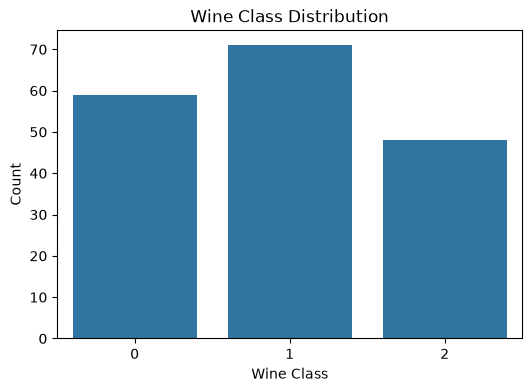

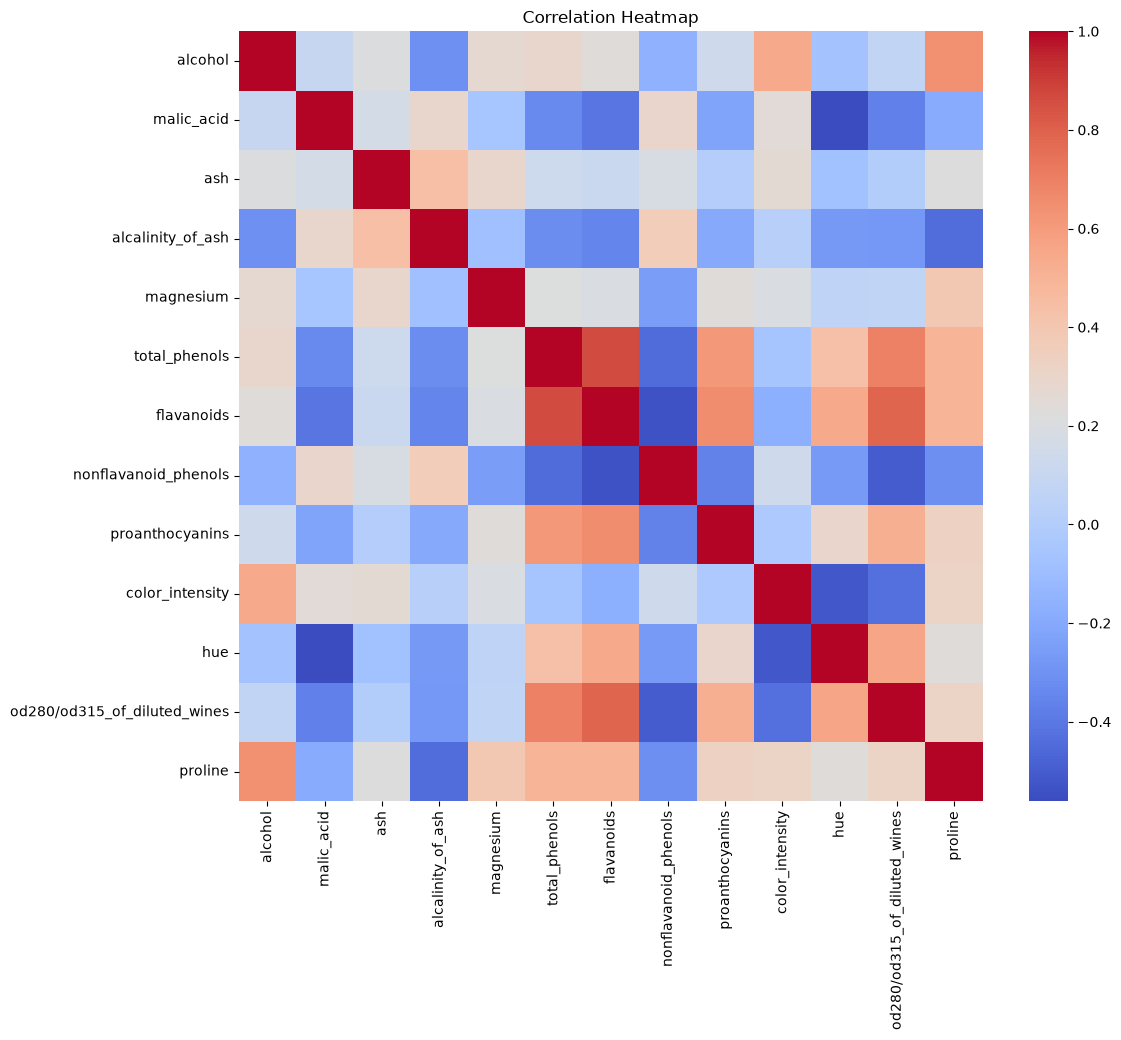

In [2]:
# ============================================================
# Step 3: Exploratory Data Analysis
# ============================================================

print("\nFirst 5 Rows:")
print(X.head())

print("\nDataset Information:")
X.info()

print("\nStatistical Summary:")
print(X.describe())

print("\nMissing Values:")
print(X.isnull().sum())

# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [4]:
# ============================================================
# Step 4: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 142
Testing Samples: 36


In [5]:
# ============================================================
# Step 5: Train Decision Tree using Gini
# ============================================================

dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)



Confusion Matrix:
[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]

Accuracy: 0.9444444444444444

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



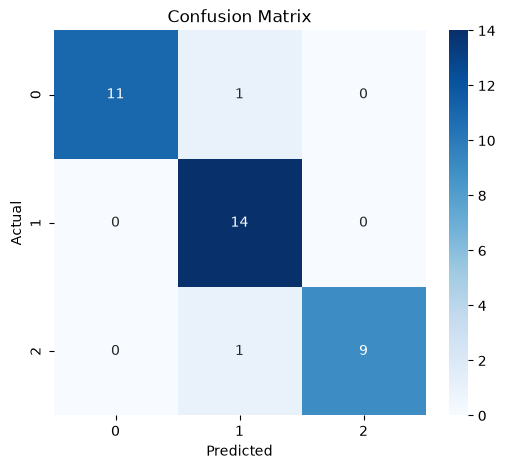

In [6]:
# ============================================================
# Step 6: Evaluation
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [7]:

# ============================================================
# Step 7: Hyperparameter Tuning
# ============================================================

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_


Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [8]:
# ============================================================
# Step 8: Evaluate Tuned Model
# ============================================================

y_pred_best = best_model.predict(X_test)

print("\nTuned Model Accuracy:",
      accuracy_score(y_test, y_pred_best))

print("\nTuned Classification Report:")
print(classification_report(y_test, y_pred_best))



Tuned Model Accuracy: 1.0

Tuned Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

